
# Generative AI and Modern Applications

## Text Generation: It's Just Statistics

At its core, a Generative LLM is a **Next-Token Prediction Engine**. It doesn't "know" facts; it knows probabilities. Given the sequence "The sky is", it calculates the probability distribution for the next word:

-   "blue": 80%
-   "gray": 15%
-   "falling": 1%

It samples from this distribution to generate text.

## Retrieval-Augmented Generation (RAG)

LLMs have two major flaws:

1.  **Hallucination**: They make things up.
2.  **Cut-off Date**: They don't know current events or private company data.

**RAG** helps mitigate this by connecting the LLM to an external knowledge source (such as a vector database).

-   **Step 1 (Retrieve)**: User asks a question. System searches the database for relevant documents.
-   **Step 2 (Augment)**: System pastes those documents into the prompt context.
-   **Step 3 (Generate)**: LLM answers the question using the provided context.

### What are Embeddings? (The Secret Sauce)

Before diving into RAG, we need to understand \*Embeddings\*—vectors that capture meaning.

-   An **Embedding** is a list of numbers (e.g., 768 floats) representing a word, sentence, or document.
-   **Key Property**: Similar meanings → Similar vectors (measured by cosine similarity).
-   "King" and "Queen" are close in embedding space; "King" and "Banana" are far apart.

Modern RAG uses dedicated **sentence embedding models** instead of plain keyword matching. This enables semantic search: "What's the price?" can match "Product A costs $50" even without exact shared words.

## Practical Demonstration: Building a "Tiny RAG"

We will simulate a RAG system that answers questions about a fictional company using a private knowledge base.

### The Knowledge Base

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Our "Private" Database (LLM doesn't know this)
documents = [
    "Product A costs $50 and includes a 1-year warranty.",
    "Product B is a subscription service costing $10/month.",
    "Support is available 24/7 via email at help@example.com.",
    "The CEO of the company is Jane Doe."
]

# Indexing (Simple TF-IDF with basic cleanup)
# Keep single-letter product IDs (A/B) by excluding them from stopwords.
custom_stopwords = list(set(ENGLISH_STOP_WORDS) - {"a", "b"})
vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    token_pattern=r"(?u)\b\w+\b",
)
doc_vectors = vectorizer.fit_transform(documents)

print(f"Indexed {len(documents)} documents.")

Indexed 4 documents.


### The Retrieval System

When a user asks a question, we find the most similar document.

In [2]:
def retrieve_info(query):
    # Vectorize query
    query_vec = vectorizer.transform([query])

    # Calculate similarity
    similarities = cosine_similarity(query_vec, doc_vectors).flatten()

    # Find best match
    best_idx = int(np.argmax(similarities))
    return best_idx, float(similarities[best_idx]), similarities

user_query = "How much does Product A cost?"
best_idx, best_score, _ = retrieve_info(user_query)
retrieved_doc = documents[best_idx]

print(f"Query: {user_query}")
print(f"Best Match Score: {best_score:.3f}")
print(f"Retrieved Context: {retrieved_doc}")

Query: How much does Product A cost?
Best Match Score: 0.554
Retrieved Context: Product A costs $50 and includes a 1-year warranty.


### The Limitation of Keyword Matching

TF-IDF still matches **surface words**, not true semantics. Watch where it works vs fails:

In [3]:
tests = [
    ("How much does Product A cost?", 0),  # Expected: Product A doc
    ("How much is the monthly plan?", 1),  # Expected: Product B doc (often fails)
    ("What's the refund policy?", -1),     # Expected: no relevant doc in KB
]

print("TF-IDF Retrieval Results:")
print("-" * 50)
for q, expected_idx in tests:
    best_idx, score, sims = retrieve_info(q)
    result = documents[best_idx]

    if expected_idx == -1:
        status = "NO-GOOD-MATCH"
    else:
        status = "OK" if best_idx == expected_idx else "MISMATCH"

    print(f"Q: {q}")
    print(f"Expected: {expected_idx if expected_idx >= 0 else 'none'} | Retrieved: {best_idx} | {status}")
    print(f"Best score: {score:.3f}")
    print(f"→ {result[:60]}...")
    print()

TF-IDF Retrieval Results:
--------------------------------------------------
Q: How much does Product A cost?
Expected: 0 | Retrieved: 0 | OK
Best score: 0.554
→ Product A costs $50 and includes a 1-year warranty....

Q: How much is the monthly plan?
Expected: 1 | Retrieved: 0 | MISMATCH
Best score: 0.000
→ Product A costs $50 and includes a 1-year warranty....

Q: What's the refund policy?
Expected: none | Retrieved: 0 | NO-GOOD-MATCH
Best score: 0.000
→ Product A costs $50 and includes a 1-year warranty....



**Observation**: Even after basic cleanup, TF-IDF can fail on paraphrases or missing concepts because it relies on lexical overlap. Real RAG systems use **semantic embeddings** (sentence-transformers) that capture meaning beyond exact words.

### The Generation (Augmented Prompt)

Now we feed the retrieved context to a small LLM.

To keep the classroom output less confusing, we use deterministic decoding and a small post-processing step.

In [4]:
from transformers import pipeline
import re

# Load a small text generator (for demonstration only)
generator = pipeline('text-generation', model='gpt2')

# Construct a constrained augmented prompt
prompt = (
    "Answer using ONLY the context below. "
    "If the answer is not present, reply: I don't know.\n"
    f"Context: {retrieved_doc}\n"
    f"Question: {user_query}\n"
    "Answer:"
)

output = generator(
    prompt,
    max_new_tokens=20,
    do_sample=False,          # deterministic output (less confusing in class)
    return_full_text=False,   # keep only generated continuation
    pad_token_id=50256,
)

raw = output[0]["generated_text"].strip()
# Keep only the first line/sentence to avoid drift into extra continuation.
answer_line = raw.split("\n")[0].strip()
answer = re.split(r"(?<=[.!?])\s+", answer_line, maxsplit=1)[0]

print(f"Prompt question: {user_query}")
print(f"Retrieved context: {retrieved_doc}")
print(f"Model answer: {answer}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'pad_token_id', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=20) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Prompt question: How much does Product A cost?
Retrieved context: Product A costs $50 and includes a 1-year warranty.
Model answer: Product A costs $50 and includes a 1-year warranty.


**Observation**: Augmented context steers the answer, but small/base models may still drift. Production RAG systems add stronger retrieval, better models, and grounding checks.

## Introduction to Diffusion Models (Image Gen)

Models like **Stable Diffusion** and **DALL-E** work differently from LLMs. They rely on **Diffusion**.

### How it works

1.  **Forward Process (Training)**: Take a clear image and slowly add "static" (Gaussian Noise) until it is pure random noise. The model watches this and learns the mathematical pattern of how the image was destroyed.
2.  **Reverse Process (Generation)**: Start with pure random noise. Ask the model: **"If this was a picture of a cat, how would you remove the noise?"** Repeat this 50 times until a clear image emerges.

### How Text Guides Generation (Conditioning)

But how does "a cat wearing a hat" become an image? The secret is **Conditioning**:

1.  **CLIP Encoder**: A separate model (trained on image-text pairs) converts your text prompt into an embedding vector.
2.  **Guided Denoising**: At each step, the diffusion model asks: "What noise should I remove to make this image **more similar** to the text embedding?"
3.  **Iterative Refinement**: After 20-50 steps, the noise becomes a coherent image matching your description.

This is why prompt engineering matters for image generation too—different phrasings produce different CLIP embeddings, leading to different images.

## Practical Demonstration: The Forward Process

We can visualize how the model learns by destroying an image ourselves.

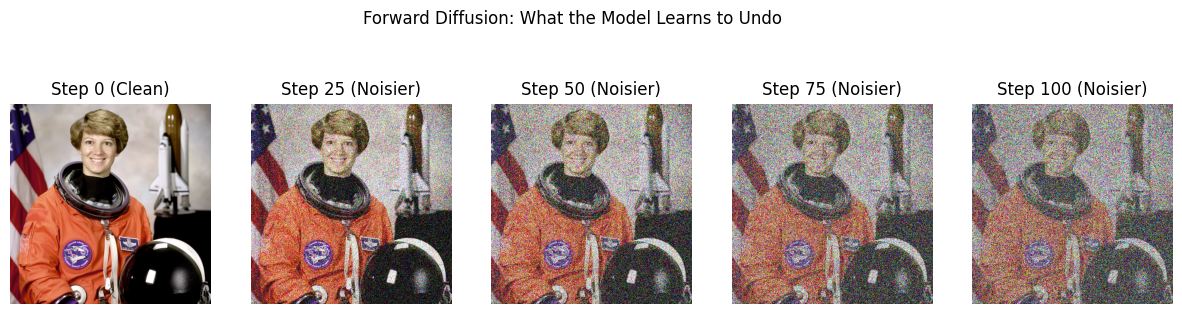

In [5]:
import matplotlib.pyplot as plt
from skimage import data
import numpy as np

# Load sample image (Astronaut)
img = data.astronaut()

# Normalize to 0-1
img = img / 255.0

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
axes[0].imshow(img)
axes[0].set_title("Step 0 (Clean)")
axes[0].axis('off')

# Simulate Forward Diffusion (Adding Noise)
current_img = img.copy()
noise_level = 0.3 # How much noise to add per step

for i in range(1, 5):
    # Add Gaussian Noise
    noise = np.random.normal(0, noise_level, img.shape)
    current_img = current_img + noise

    # Clip to stay valid color range
    current_img = np.clip(current_img, 0, 1)

    axes[i].imshow(current_img)
    axes[i].set_title(f"Step {i*25} (Noisier)")
    axes[i].axis('off')

plt.suptitle("Forward Diffusion: What the Model Learns to Undo")
plt.show()

**Note**: This is a simplified visualization. Real diffusion models use a carefully designed noise schedule and closed-form noising process.

## Optional Demonstration: Real Image Generation (Diffusion)

The next cell is optional and intended for GPU-enabled environments.

-   It requires the `diffusers` package.
-   It is much slower than the forward-noise demo.
-   On first run, the model weights must be downloaded.

If generation cannot run, the cell falls back to a cached image if available.

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /home/camarocico/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /home/camarocico/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/25 [00:00<?, ?it/s]

Generated and saved: data/diffusion_example.png


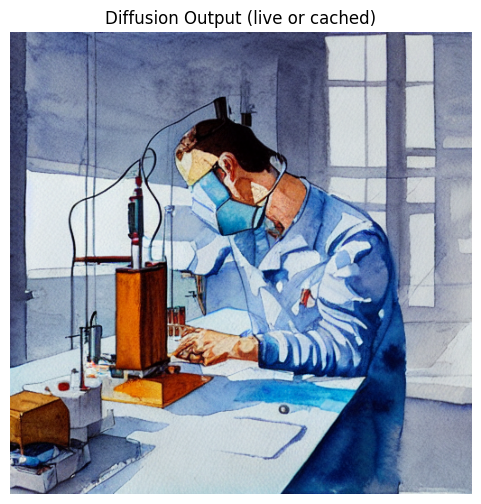

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import torch

prompt = "A watercolor painting of a robot scientist in a Dutch lab, soft morning light, detailed"
out_path = Path("data/diffusion_example.png")

generated = False
try:
    # Use an explicit pipeline import. AutoPipeline can import optional
    # modules that may fail in some environments.
    from diffusers import StableDiffusionPipeline

    if torch.cuda.is_available():
        model_id = "runwayml/stable-diffusion-v1-5"
        pipe = StableDiffusionPipeline.from_pretrained(
            model_id,
            torch_dtype=torch.float16,
        ).to("cuda")

        image = pipe(
            prompt=prompt,
            num_inference_steps=25,
            guidance_scale=7.5,
            height=512,
            width=512,
        ).images[0]

        out_path.parent.mkdir(parents=True, exist_ok=True)
        image.save(out_path)
        generated = True
        print(f"Generated and saved: {out_path}")
    else:
        print("Skipping live generation: CUDA GPU not available.")
except Exception as e:
    print(f"Skipping live generation: {e}")

if out_path.exists():
    img = plt.imread(out_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title("Diffusion Output (live or cached)")
    plt.axis("off")
    plt.show()
elif not generated:
    print("No cached diffusion image found. Keep using the forward-noise demo in this environment.")

## Ethical Considerations and Bias

With great power comes great responsibility.

### Bias

GenAI models are trained on the internet. The internet contains stereotypes, racism, and sexism.

-   **Example**: If you ask an image generator for a "Doctor," it might generate only men. If you ask for a "Nurse," it might generate only women.
-   **Mitigation**: Curating training data and using "RLHF" (Human Feedback) to penalize biased outputs.

### Hallucination

LLMs can confidently produce false statements.

-   They optimize for **plausibility**, not **truth**.
-   **Danger**: Using LLMs for medical or legal advice without verification (RAG helps reduce this).

### Copyright

-   Image models are trained on billions of copyrighted images (artists' work).
-   Code models are trained on GitHub repositories.
-   The legal framework for this is still being debated globally.

## Exercises

### RAG Query Robustness

Test how well TF-IDF handles different query phrasings.

1.  Add more documents to the knowledge base.
2.  Try queries with synonyms, typos, or completely different phrasing.
3.  Which queries fail? Why?

In [7]:
# Extended knowledge base
documents_extended = documents + [
    "Returns are accepted within 30 days with receipt.",
    "Our headquarters is located in San Francisco.",
]

# Re-index (keep settings consistent with the main retrieval demo)
vectorizer_ext = TfidfVectorizer(
    stop_words=custom_stopwords,
    token_pattern=r"(?u)\b\w+\b",
)
doc_vectors_ext = vectorizer_ext.fit_transform(documents_extended)

def retrieve_ext(query):
    query_vec = vectorizer_ext.transform([query])
    sims = cosine_similarity(query_vec, doc_vectors_ext).flatten()
    return documents_extended[np.argmax(sims)], max(sims)

# Test queries
test_queries = [
    "refund policy",           # Synonym for "returns"
    "where are you located?",  # Paraphrase
    "Prodct A price",          # Typo
]

for q in test_queries:
    doc, score = retrieve_ext(q)
    print(f"Q: {q}")
    print(f"  Score: {score:.3f} | Doc: {doc[:40]}...")

Q: refund policy
  Score: 0.000 | Doc: Product A costs $50 and includes a 1-yea...
Q: where are you located?
  Score: 0.500 | Doc: Our headquarters is located in San Franc...
Q: Prodct A price
  Score: 0.536 | Doc: Product A costs $50 and includes a 1-yea...


### Diffusion Noise Schedule

The rate at which noise is added affects image quality.

1.  Modify the `noise_level` parameter in the diffusion demo (try 0.1, 0.3, 0.6).
2.  How does the "destruction speed" change?
3.  Real diffusion models use carefully tuned **noise schedules** (linear, cosine, etc.).

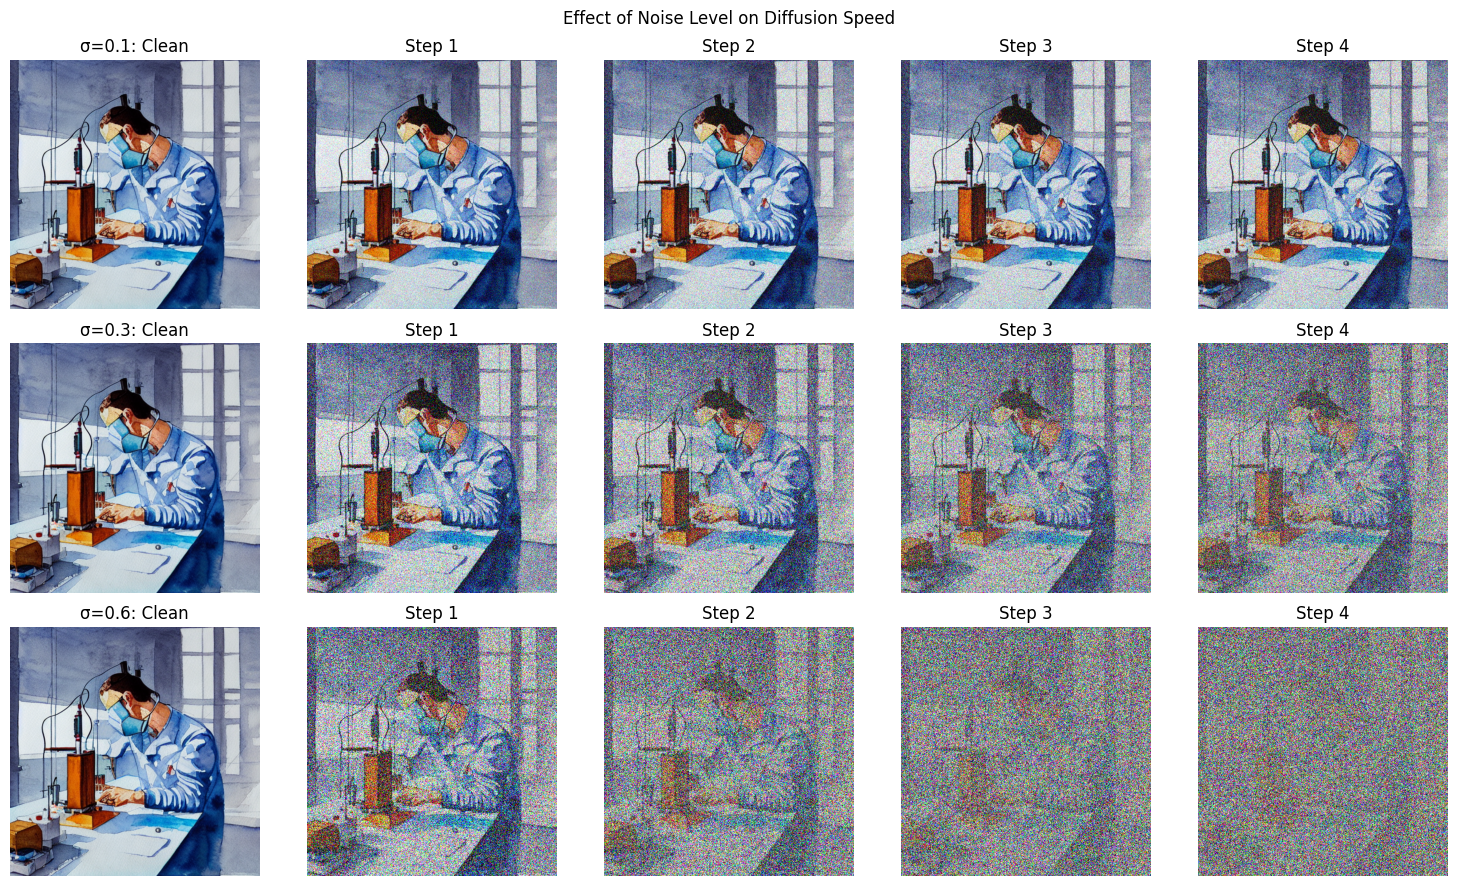

In [8]:
# Compare noise schedules
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
noise_levels = [0.1, 0.3, 0.6]

for row, nl in enumerate(noise_levels):
    current = img.copy()
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"σ={nl}: Clean")
    axes[row, 0].axis('off')

    for i in range(1, 5):
        noise = np.random.normal(0, nl, img.shape)
        current = np.clip(current + noise, 0, 1)
        axes[row, i].imshow(current)
        axes[row, i].set_title(f"Step {i}")
        axes[row, i].axis('off')

plt.suptitle("Effect of Noise Level on Diffusion Speed")
plt.tight_layout()
plt.show()

### Emerging Paradigm: AI Agents

Modern GenAI goes beyond chat. **AI Agents** combine LLMs with tools:

-   **Code Execution**: The LLM writes Python and runs it.
-   **Web Search**: The LLM searches the internet for current information.
-   **Tool Use**: The LLM calls APIs (calculators, databases, etc.).

This is the frontier of GenAI—systems that **act**, not just **respond**.

## Summary

1.  **Next-Token Prediction**: The simple math behind the complex magic of LLMs.
2.  **RAG**: The bridge between a generic LLM and your private data.
3.  **Diffusion**: Creating images by learning to reverse-engineer noise.
4.  **Ethics**: AI reflects the data it was fed. It requires human oversight.